# Trabajo Práctico I - Visualización por Computadora I

In [13]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

---
## Parte 1: White Patch

White patch es operador de pixel utilizado para hacer un balance de blancos automático. Su implementación matemática es

$$
(R;G;B) = (255*\frac{R_{x,y}}{R_{\max}};255*\frac{G_{x,y}}{G_{\max}};255*\frac{B_{x,y}}{B_{\max}})
$$

Desde la fórmula, se pueden intuir algunas limitaciones, como la *sensibilidad al ruido:* Un solo píxel de ruido muy brillante puede engañar al algoritmo y arruinar el balance de color.

In [14]:
# Implementamos el algoritmo de White Patch en Python
def white_patch(image):
    result = image.copy().astype(np.float64)
    for c in range(3):
        max_val = result[:, :, c].max()
        if max_val > 0:
            result[:, :, c] = result[:, :, c] * (255.0 / max_val)
    return np.clip(result, 0, 255).astype(np.uint8)

### Cargamos el primer set de imágenes

In [15]:
wp_files = {
    'Roja (png)': 'material/white_patch/wp_red.png',
    'Roja (jpg)': 'material/white_patch/wp_red2.jpg',
    'Verde (png)': 'material/white_patch/wp_green.png',
    'Verde (jpg)': 'material/white_patch/wp_green2.jpg',
    'Azul (jpg)': 'material/white_patch/wp_blue.jpg',
}

images = {}
for name, path in wp_files.items():
    img = cv.imread(path)
    images[name] = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    print(f'{name}: {img.shape}')

Roja (png): (813, 481, 3)
Roja (jpg): (1600, 1200, 3)
Verde (png): (571, 363, 3)
Verde (jpg): (1600, 1200, 3)
Azul (jpg): (1600, 1200, 3)


### Aplicamos White Patch y comparamos resultados

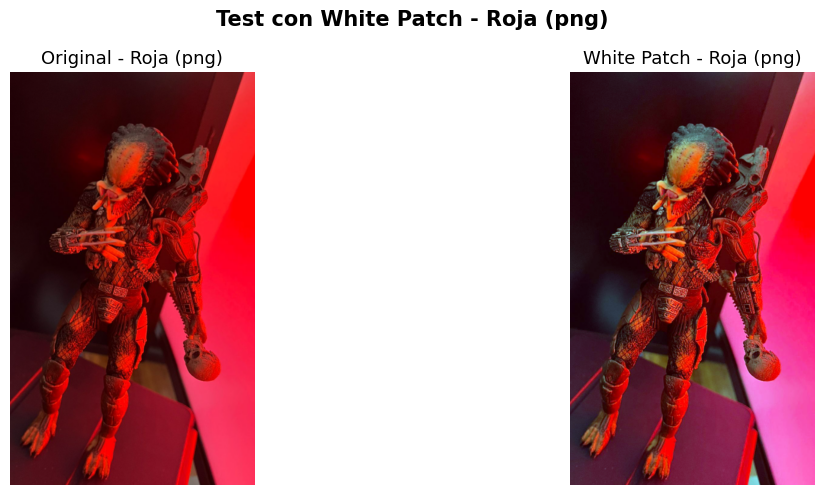

Original  -> R max=255, G max=134, B max=122
Corregida -> R max=255, G max=255, B max=255



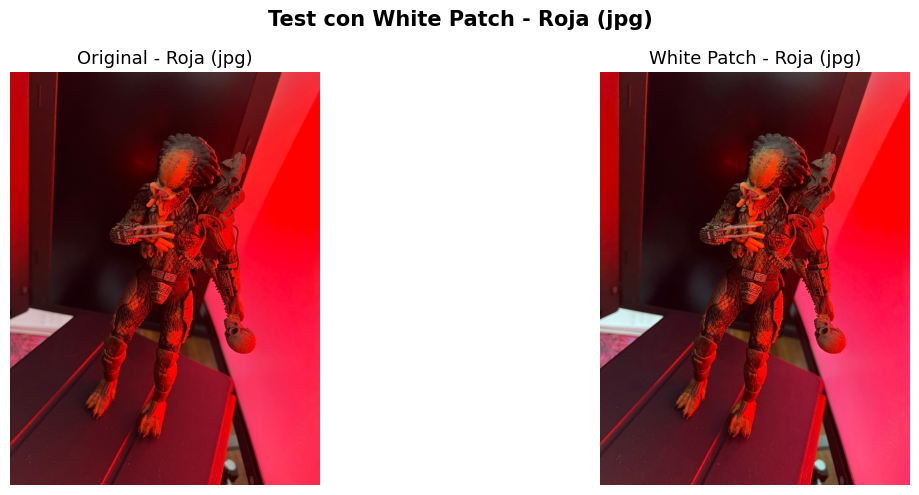

Original  -> R max=255, G max=201, B max=203
Corregida -> R max=255, G max=255, B max=254



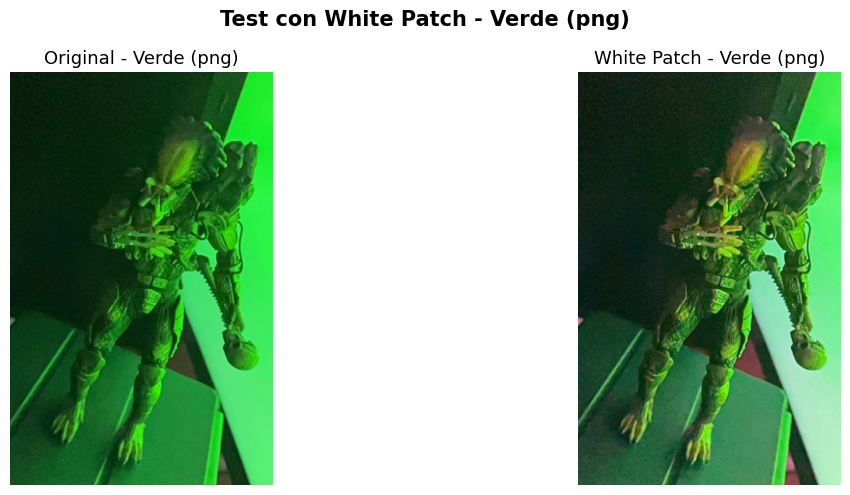

Original  -> R max=126, G max=252, B max=155
Corregida -> R max=255, G max=255, B max=255



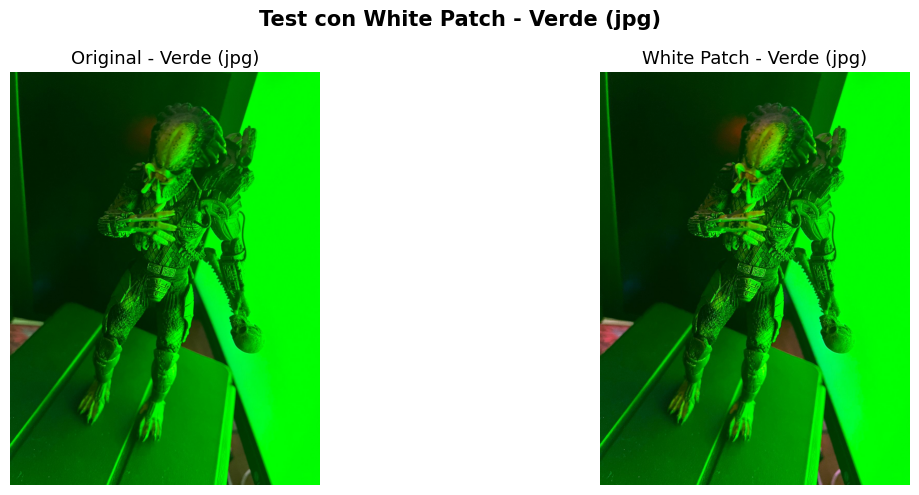

Original  -> R max=170, G max=255, B max=172
Corregida -> R max=255, G max=255, B max=255



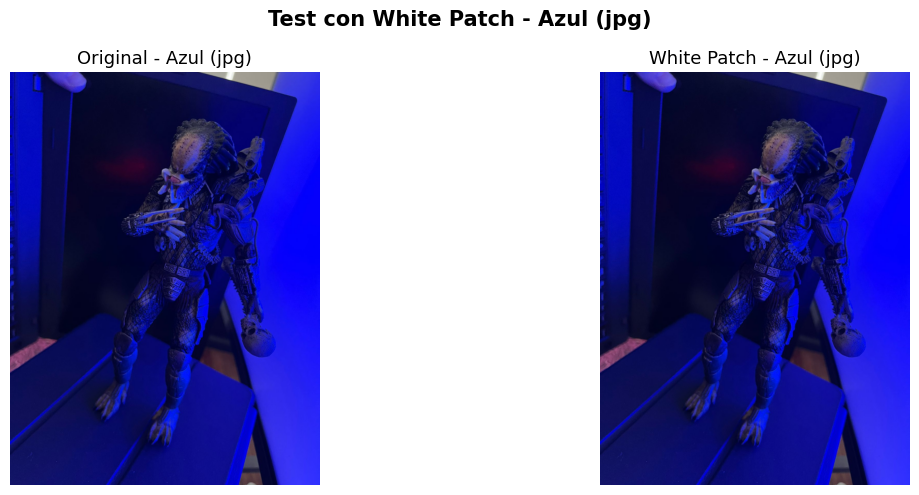

Original  -> R max=255, G max=255, B max=255
Corregida -> R max=255, G max=255, B max=255



In [16]:
for name, img in images.items():
    corrected = white_patch(img)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].imshow(img)
    axes[0].set_title(f'Original - {name}', fontsize=13)
    axes[0].axis('off')
    
    axes[1].imshow(corrected)
    axes[1].set_title(f'White Patch - {name}', fontsize=13)
    axes[1].axis('off')
    
    fig.suptitle(f'Test con White Patch - {name}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Original  -> R max={img[:,:,0].max()}, G max={img[:,:,1].max()}, B max={img[:,:,2].max()}')
    print(f'Corregida -> R max={corrected[:,:,0].max()}, G max={corrected[:,:,1].max()}, B max={corrected[:,:,2].max()}')
    print()

### White Patch sobre imágenes de manos

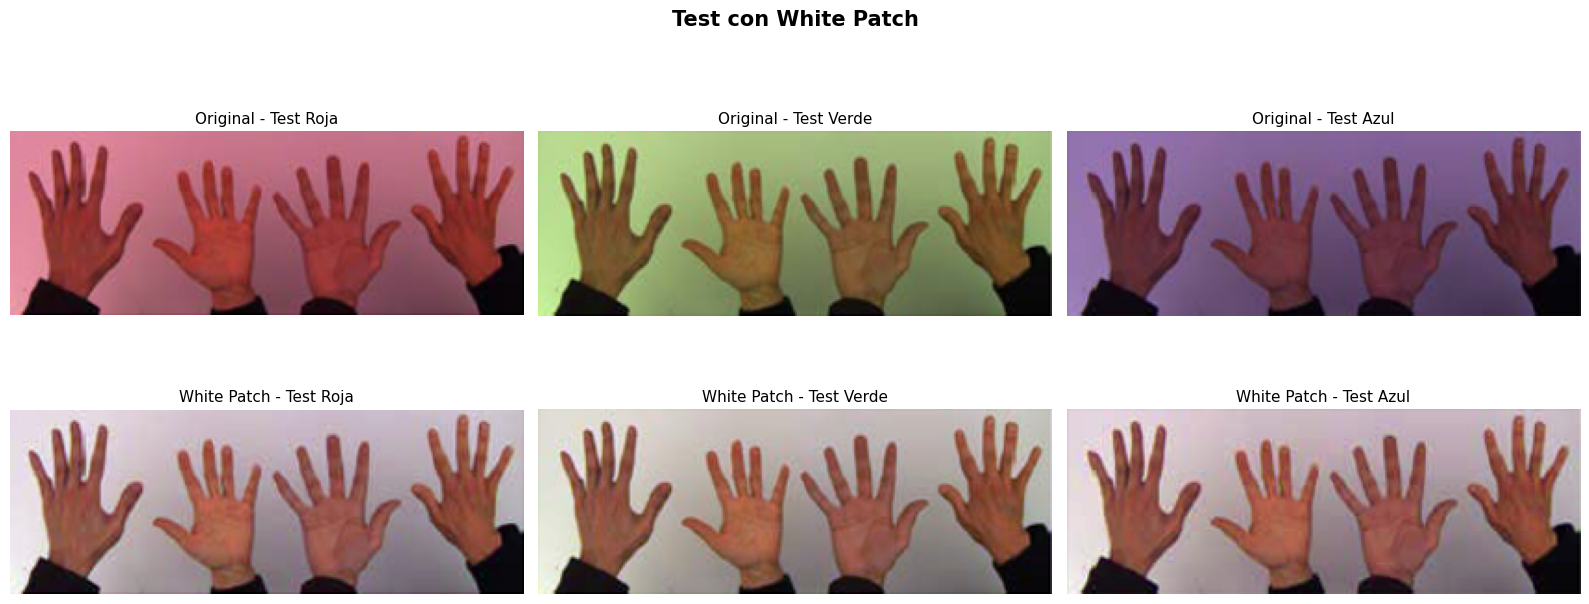

In [17]:
# Cargamos segundo set de imagenes
test_files = {
    'Test Roja': 'material/white_patch/test_red.png',
    'Test Verde': 'material/white_patch/test_green.png',
    'Test Azul': 'material/white_patch/test_blue.png',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for idx, (name, path) in enumerate(test_files.items()):
    img = cv.cvtColor(cv.imread(path), cv.COLOR_BGR2RGB)
    corrected = white_patch(img)
    
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f'Original - {name}', fontsize=11)
    axes[0, idx].axis('off')
    
    axes[1, idx].imshow(corrected)
    axes[1, idx].set_title(f'White Patch - {name}', fontsize=11)
    axes[1, idx].axis('off')

fig.suptitle('Test con White Patch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Histogramas por canal (antes y después)

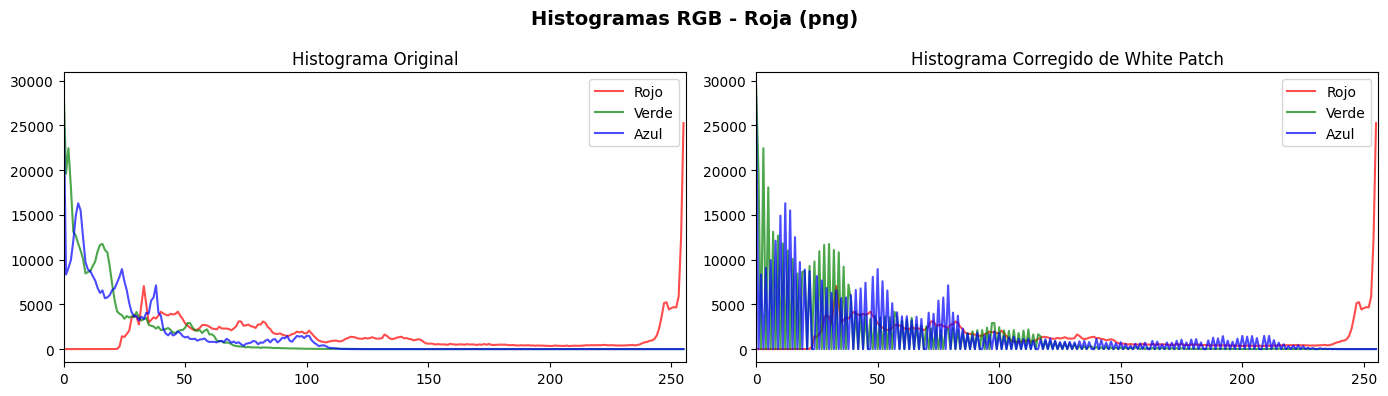

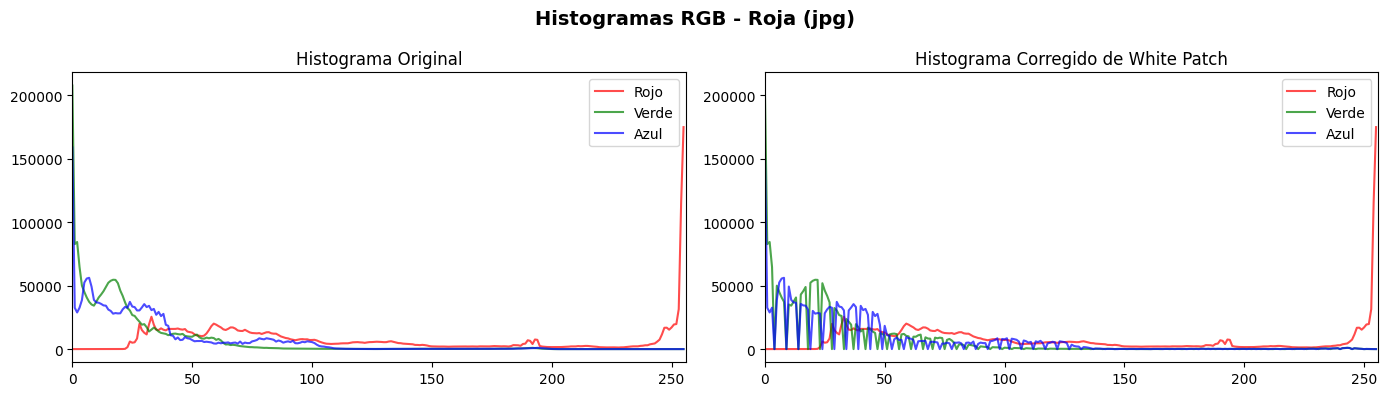

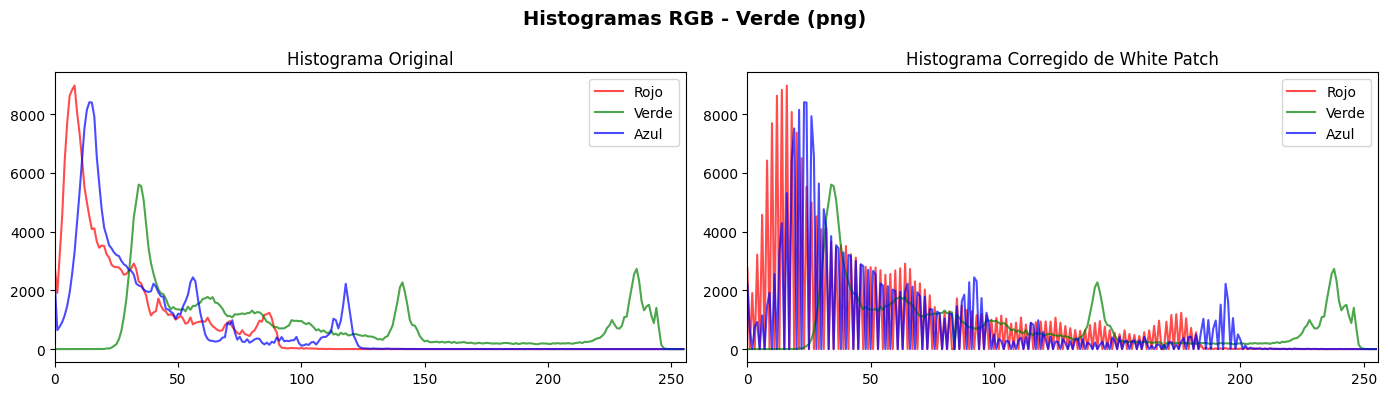

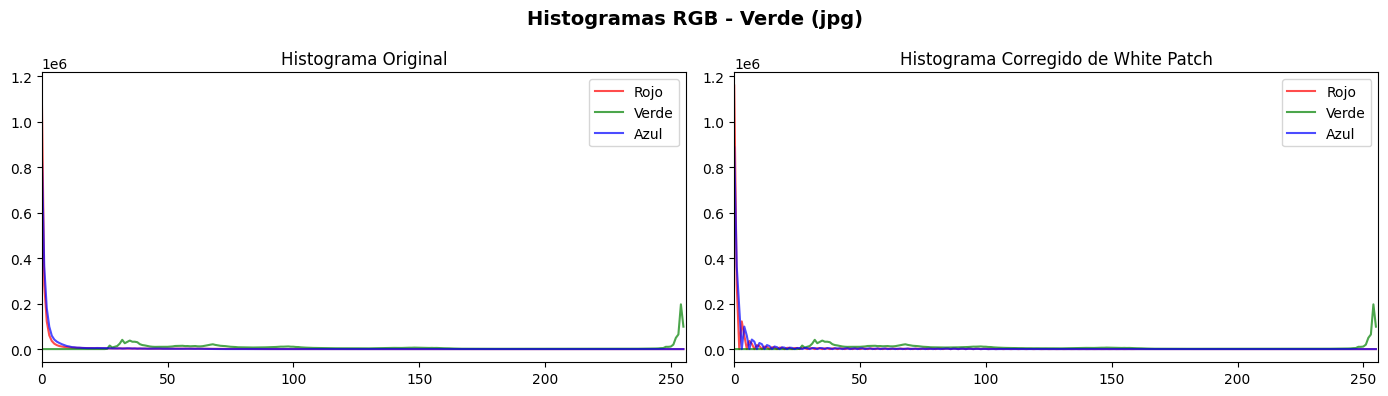

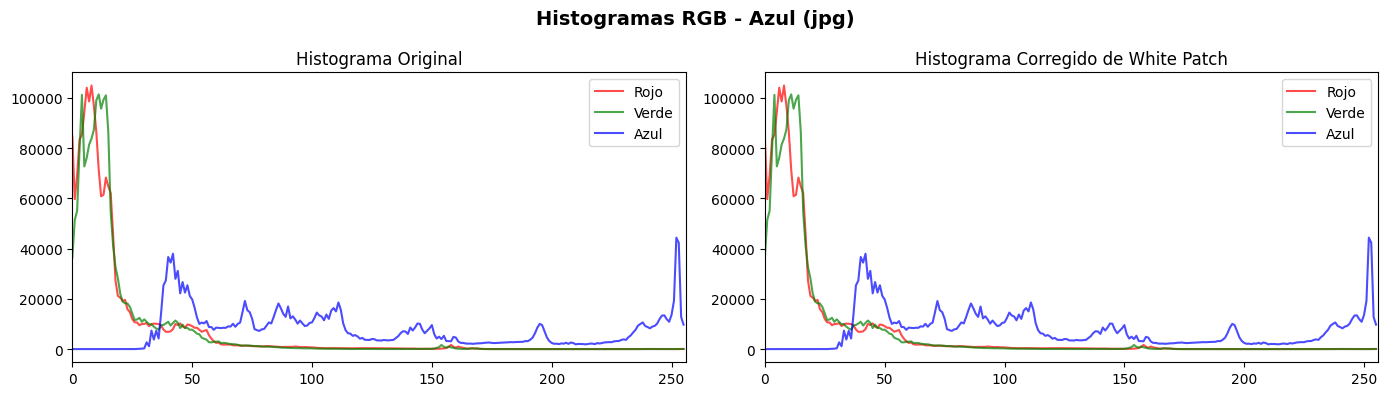

In [18]:
def plot_rgb_histograms(img_original, img_corrected, title):
    colors = ('r', 'g', 'b')
    labels = ('Rojo', 'Verde', 'Azul')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    for i, (color, label) in enumerate(zip(colors, labels)):
        hist_orig = cv.calcHist([img_original], [i], None, [256], [0, 256])
        hist_corr = cv.calcHist([img_corrected], [i], None, [256], [0, 256])
        axes[0].plot(hist_orig, color=color, label=label, alpha=0.7)
        axes[1].plot(hist_corr, color=color, label=label, alpha=0.7)
    
    axes[0].set_title('Histograma Original')
    axes[0].legend()
    axes[0].set_xlim([0, 256])
    
    axes[1].set_title('Histograma Corregido de White Patch')
    axes[1].legend()
    axes[1].set_xlim([0, 256])
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

for name, img in images.items():
    corrected = white_patch(img)
    plot_rgb_histograms(img, corrected, f'Histogramas RGB - {name}')

### Conclusion del algoritmo White Patch: posibles fallas

Como se observó en la fórmula, White Patch es un algoritmo sensible a valores máximos. En el caso de la imagen roja en `png`, con valores RBG máximos de 255, 134 y 122, el postprocesado revela colores previamente ocultos. Sin embargo, en el caso de la azul en `jpg`, hay una pequeña zona muy blanca. Por este motivo, los valores máximos son idénticos en la imagen tanto procesada como sin procesar (255, 255, 255). Esta pequeña zona blanca en la azul (`jpg`) hace que White Patch no modifique la imagen.

## Conclusiones de aplicar White Patch en "El Depredador"

*Imágenes*
- Se observa que, en los casos de las imágenes verdes y rojas, al aplicar White Patch se muestran detalles de colores que estaban ocultos en la imagen original, puntualmente en la cabeza del depredador, se observa una coloración de un tono verdoso en ambos casos.

- Sin embargo, en las imágenes de color azul, no se nota ningún cambio de coloración aparente, o por lo menos es imperceptible.

- Por otro lado, en el caso de las imágenes PNG, al pasar por White Patch, parece saturarse el blanco de la pared lateral derecha de la imagen. En cambio, en el caso de las JPG se neutraliza esa saturación.


## Conclusiones de aplicar White Patch en "Imagenes de manos"

- Se observa que, en todos los casos hay una atenuación del fondo de la imagen. No es perfecta en los casos del color rojo y azul, pero en el verde es casi total.

- En el caso del azul, se observa una decoloración del fondo, pero también se puede ver que la original no era azul completamente sino más bien algo púrpura, por lo que tiene componentes del rojo. Esto, según se aprecia en la imagen roja, no se logra atenuar completamente las componentes rojas de las imágenes.

## Conclusiones sobre los Histogramas

- Según se aprecia en los histogramas, en los casos de las imágnees rojas y verdes, hay un realce de todas las componentes mientras que la predominante (roja y verde en cada caso) se mantiene casi inmutable.

- En el caso de las imágenes azules la corrección de white patch no parece afectar el histograma, lo cual concuerda con lo observable en las imágenes.


---
## Parte 2: Histogramas en escala de grises

### Cargamos imagenes en escala de grises y visualizarlas

img1_tp.png: shape=(288, 287), dtype=uint8, min=2, max=255
img2_tp.png: shape=(288, 287), dtype=uint8, min=2, max=255


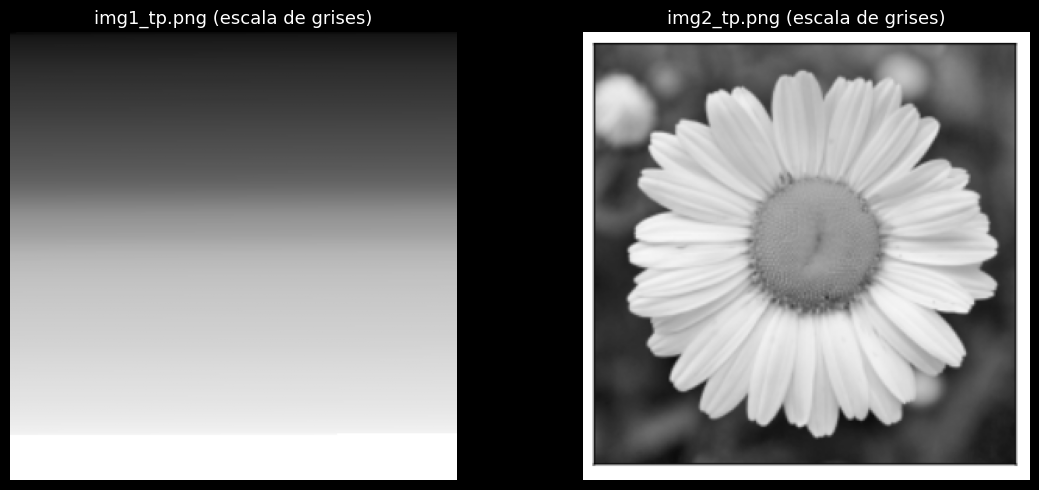

In [39]:
img1 = cv.imread('material/img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('material/img2_tp.png', cv.IMREAD_GRAYSCALE)

print(f'img1_tp.png: shape={img1.shape}, dtype={img1.dtype}, min={img1.min()}, max={img1.max()}')
print(f'img2_tp.png: shape={img2.shape}, dtype={img2.dtype}, min={img2.min()}, max={img2.max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1_tp.png (escala de grises)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2_tp.png (escala de grises)', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Histogramas de las imágenes

Elegimos 64 bins, suficiente resolución para ver la distribución de intensidades sin el ruido que generaría usar 256 bins en imágenes pequeñas. También mostramos con 256 bins para comparación.

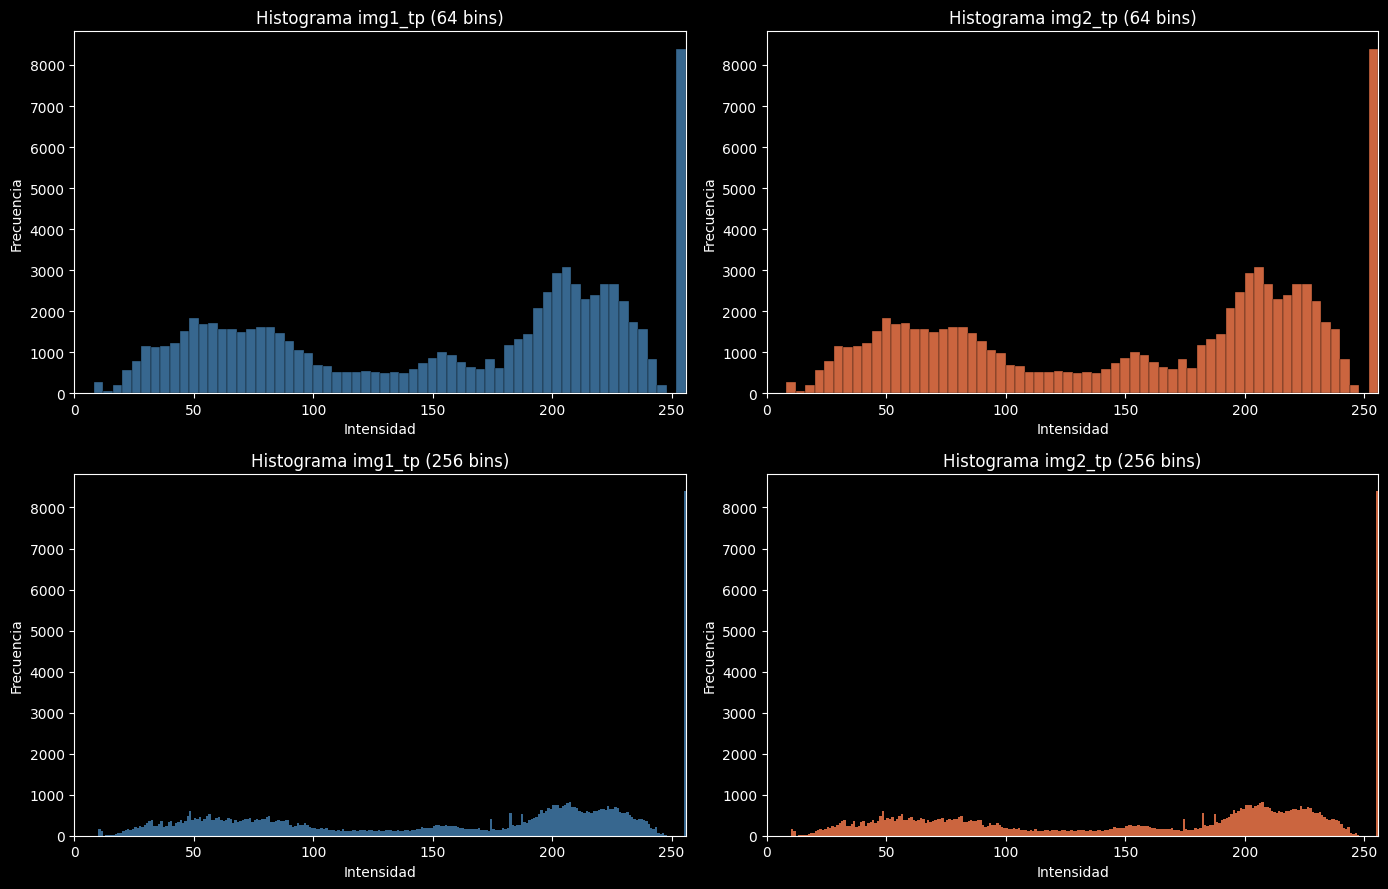

In [40]:
n_bins = 64

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histograma img1 - 64 bins
axes[0, 0].hist(img1.ravel(), bins=n_bins, range=(0, 256), color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0, 0].set_title(f'Histograma img1_tp ({n_bins} bins)', fontsize=12)
axes[0, 0].set_xlabel('Intensidad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_xlim([0, 256])

# Histograma img2 - 64 bins
axes[0, 1].hist(img2.ravel(), bins=n_bins, range=(0, 256), color='coral', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0, 1].set_title(f'Histograma img2_tp ({n_bins} bins)', fontsize=12)
axes[0, 1].set_xlabel('Intensidad')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_xlim([0, 256])

# Histograma img1 - 256 bins
axes[1, 0].hist(img1.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
axes[1, 0].set_title(f'Histograma img1_tp (256 bins)', fontsize=12)
axes[1, 0].set_xlabel('Intensidad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_xlim([0, 256])

# Histograma img2 - 256 bins
axes[1, 1].hist(img2.ravel(), bins=256, range=(0, 256), color='coral', alpha=0.8)
axes[1, 1].set_title(f'Histograma img2_tp (256 bins)', fontsize=12)
axes[1, 1].set_xlabel('Intensidad')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Comparación superpuesta de histogramas

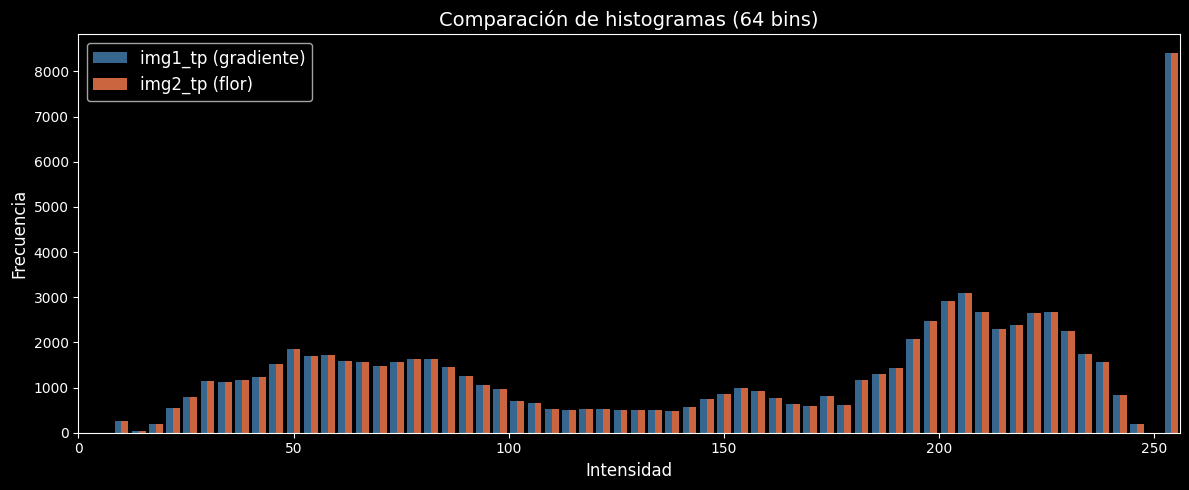

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))

hist1, bins = np.histogram(img1.ravel(), bins=n_bins, range=(0, 256))
hist2, _    = np.histogram(img2.ravel(), bins=n_bins, range=(0, 256))

bin_centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0]) * 0.4

ax.bar(bin_centers - width/2, hist1, width=width, color='steelblue', alpha=0.8, label='img1_tp (gradiente)')
ax.bar(bin_centers + width/2, hist2, width=width, color='coral', alpha=0.8, label='img2_tp (flor)')

ax.set_title('Comparación de histogramas (64 bins)', fontsize=14)
ax.set_xlabel('Intensidad', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.legend(fontsize=12)
ax.set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Histogramas normalizados

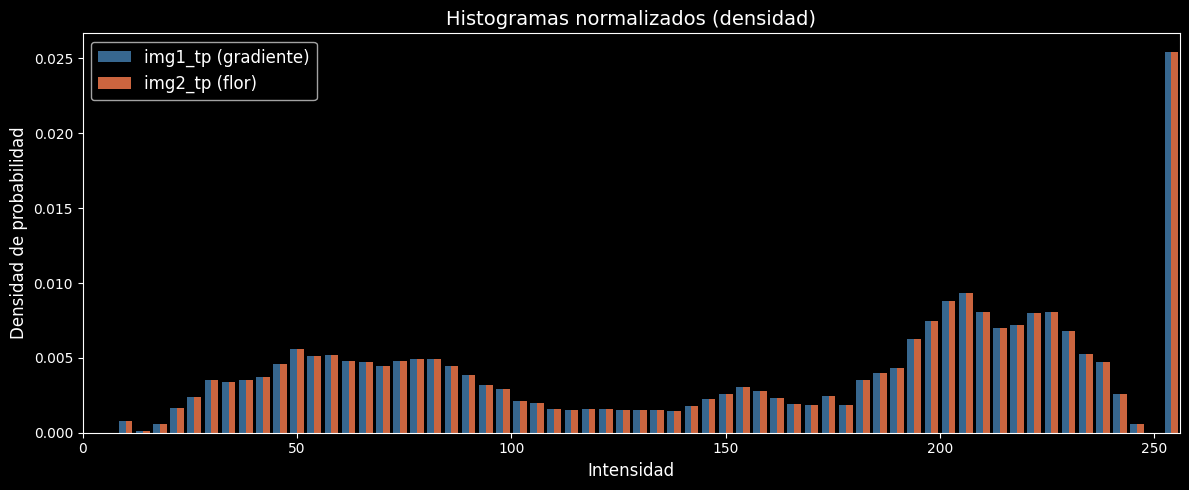

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

hist1, bins = np.histogram(img1.ravel(), bins=n_bins, range=(0, 256), density=True)
hist2, _    = np.histogram(img2.ravel(), bins=n_bins, range=(0, 256), density=True)

bin_centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0]) * 0.4

ax.bar(bin_centers - width/2, hist1, width=width, color='steelblue', alpha=0.8, label='img1_tp (gradiente)')
ax.bar(bin_centers + width/2, hist2, width=width, color='coral', alpha=0.8, label='img2_tp (flor)')

ax.set_title('Histogramas normalizados (densidad)', fontsize=14)
ax.set_xlabel('Intensidad', fontsize=12)
ax.set_ylabel('Densidad de probabilidad', fontsize=12)
ax.legend(fontsize=12)
ax.set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Estadisticas de intensidad

In [43]:
print(f'img1_tp -> Media: {img1.mean():.2f}, Std: {img1.std():.2f}, Mediana: {np.median(img1):.1f}')
print(f'img2_tp -> Media: {img2.mean():.2f}, Std: {img2.std():.2f}, Mediana: {np.median(img2):.1f}')

img1_tp -> Media: 154.81, Std: 75.34, Mediana: 182.0
img2_tp -> Media: 154.81, Std: 75.34, Mediana: 182.0


### Conclusiones

Luego de graficar los histogramas y compararlos entre sí, se observa que son idénticos. Tanto si se toman 64 bins como 256 bins. Esto indica que basado en el histograma, si se llegara a entrenar algún modelo de detección/clasificación con estos como features, el modelo diría que son la misma imagen. Esto se debería a que el histograma sólo está proporcionando información acerca del conteo de pixeles y *no* sobre su ubicación o distribución, con lo cual dos imágenes diferentes pueden tener un conteo de pixeles igual. Por lo tanto, se pone en evidencia que los histogramas son features de baja utilidad en modelos de clasificación/detección de imagenes.